
# Chartmetric API — Pilotos 1 y 2

Objetivo: construir trayectorias digitales mensuales de artistas hasta **2026-03-31 inclusive**, usando sólo métricas transparentes de las plataformas originales.

## Fan Stats

Endpoint: `GET /api/artist/{id}/stat/{source}`

Se consulta **sin `field`** para inspeccionar los campos default de cada source.

Sources y variables objetivo:

- `spotify`: `followers`, `listeners`
- `twitter`: `followers`
- `youtube_channel`: `subscribers`, `views`
- `youtube_artist`: `monthly_views`
- `instagram`: `followers`
- `tiktok`: `followers`, `likes`

Son **6 requests máximos por artista**. El código pide desde una fecha deliberadamente temprana hasta `2026-03-31`; si Chartmetric dispone de menos historia, se conserva únicamente lo que devuelve.

## Playlist Evolution

Endpoint: `GET /api/playlist/by/artist/{id}/evolution`

La documentación actual lo define como una serie diaria y no documenta parámetros de fecha ni paginación. Por eso el piloto realiza **una sola llamada por artista** y luego inspecciona el rango temporal efectivamente devuelto.

Se conservan:

- Spotify: `playlist_count`, `ed_playlist_count`, `playlist_total_reach`, `ed_playlist_total_reach`
- YouTube: `playlist_count`, `ed_playlist_count`, `playlist_total_reach`, `ed_playlist_total_reach`
- Amazon: `playlist_count`, `ed_playlist_count`

## Regla central para ahorrar requests

Antes de llamar a la API, cada función verifica:

1. si la respuesta cruda ya existe en el cache local;
2. si el log registra el request como completado;
3. sólo si no existe ninguna de esas dos evidencias, llama a Chartmetric.

La respuesta cruda se guarda **antes de parsearla**. Así, si aparece un error local después de una descarga exitosa, se puede re-procesar sin repetir el request.

El archivo analítico acumulado sigue siendo uno solo: `chartmetric_raw_long.rds`. El cache crudo es un archivo técnico separado que protege las descargas ya realizadas.


In [1]:

# PAQUETES

paquetes <- c("httr", "jsonlite", "data.table", "lubridate")

faltan <- paquetes[!paquetes %in% rownames(installed.packages())]

if (length(faltan) > 0) {
  install.packages(faltan)
}

library(httr)
library(jsonlite)
library(data.table)
library(lubridate)



Adjuntando el paquete: 'lubridate'


The following objects are masked from 'package:data.table':

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


The following objects are masked from 'package:base':

    date, intersect, setdiff, union




## 1. Configuración

In [2]:

# CONFIGURACIÓN GENERAL

BASE_URL <- "https://api.chartmetric.com"

# El estudio termina en marzo de 2026 inclusive.
END_DATE <- as.Date("2026-03-31")

# Fecha deliberadamente temprana para explorar el máximo histórico
# de Fan Stats sin recortar de antemano.
FAN_SINCE <- as.Date("2010-01-01")

FAN_SOURCES <- c(
  "spotify",
  "twitter",
  "youtube_channel",
  "youtube_artist",
  "instagram",
  "tiktok"
)

TARGET_FAN_METRICS <- list(
  spotify         = c("followers", "listeners"),
  twitter         = c("followers"),
  youtube_channel = c("subscribers", "views"),
  youtube_artist  = c("monthly_views"),
  instagram       = c("followers"),
  tiktok          = c("followers", "likes")
)

TARGET_PLAYLIST_METRICS <- list(
  spotify = c(
    "playlist_count",
    "ed_playlist_count",
    "playlist_total_reach",
    "ed_playlist_total_reach"
  ),
  youtube = c(
    "playlist_count",
    "ed_playlist_count",
    "playlist_total_reach",
    "ed_playlist_total_reach"
  ),
  amazon = c(
    "playlist_count",
    "ed_playlist_count"
  )
)

# Se mantienen los mismos nombres de carpeta/archivos que en la notebook anterior
# para poder reutilizar Spotify y Twitter ya descargados.
OUT_DIR <- "chartmetric_pilotos"
dir.create(OUT_DIR, showWarnings = FALSE, recursive = TRUE)

DATA_FILE <- file.path(
  OUT_DIR,
  "chartmetric_raw_long.rds"
)

LOG_FILE <- file.path(
  OUT_DIR,
  "chartmetric_request_log.csv"
)

RAW_RESPONSE_FILE <- file.path(
  OUT_DIR,
  "chartmetric_raw_responses.rds"
)

cat("Datos procesados:", DATA_FILE, "\n")
cat("Log:", LOG_FILE, "\n")
cat("Cache crudo:", RAW_RESPONSE_FILE, "\n")


Datos procesados: chartmetric_pilotos/chartmetric_raw_long.rds 
Log: chartmetric_pilotos/chartmetric_request_log.csv 
Cache crudo: chartmetric_pilotos/chartmetric_raw_responses.rds 


## 2. Archivo maestro de artistas

In [3]:

# ARCHIVO MAESTRO: dataset_raw_concat_7000

artist_candidates <- c(
  "dataset_raw_concat_7000.csv"
)

existing_candidates <- artist_candidates[file.exists(artist_candidates)]

ARTIST_FILE <- if (length(existing_candidates) > 0) {
  existing_candidates[1]
} else {
  NA_character_
}

load_artist_catalog <- function(path = ARTIST_FILE) {

  if (is.na(path) || !file.exists(path)) {
    message(
      "No encontré dataset_raw_concat_7000 en el working directory. ",
      "Podés definir ARTIST_FILE manualmente más adelante."
    )
    return(data.table())
  }

  x <- fread(
    path,
    select = c(
      "chartmetric_id",
      "artist_name",
      "cm_artist_rank"
    )
  )

  x[, ID := as.character(chartmetric_id)]

  x <- x[
    ,
    .(
      ID,
      artist_name,
      cm_artist_rank
    )
  ]

  unique(x, by = "ID")
}

ARTISTS <- load_artist_catalog()

if (nrow(ARTISTS) > 0) {
  cat("Artistas cargados:", nrow(ARTISTS), "\n")
  print(head(ARTISTS))
}


Artistas cargados: 7000 
       ID   artist_name cm_artist_rank
   <char>        <char>          <int>
1: 214945     Bad Bunny              4
2:   2762  Taylor Swift              1
3:   3501    Bruno Mars              2
4:   3479 Justin Bieber              3
5:   3852    The Weeknd              7
6:   3380         Drake              6


## 3. Autenticación

In [4]:

# AUTENTICACIÓN
# Reutiliza el access token hasta que falte aproximadamente 1 minuto para vencer.

.cm_auth <- new.env(parent = emptyenv())
.cm_auth$token <- NULL
.cm_auth$expires_at <- as.POSIXct(NA)

get_access_token <- function(force = FALSE) {

  refresh_token <- Sys.getenv("CHARTMETRIC_REFRESH_TOKEN")

  if (refresh_token == "") {
    stop(
      "Falta CHARTMETRIC_REFRESH_TOKEN en .Renviron. ",
      "Agregalo y reiniciá el kernel de R."
    )
  }

  ahora <- Sys.time()

  vigente <- (
    !force &&
    !is.null(.cm_auth$token) &&
    !is.na(.cm_auth$expires_at) &&
    ahora < (.cm_auth$expires_at - 60)
  )

  if (vigente) {
    return(.cm_auth$token)
  }

  resp <- POST(
    paste0(BASE_URL, "/api/token"),
    body = list(refreshtoken = refresh_token),
    encode = "json",
    timeout(60)
  )

  status <- status_code(resp)
  texto <- content(resp, as = "text", encoding = "UTF-8")

  if (status != 200) {
    stop(
      "No se pudo obtener access token. HTTP ",
      status,
      "\n",
      substr(texto, 1, 1000)
    )
  }

  body <- fromJSON(
    texto,
    simplifyVector = TRUE
  )

  if (is.null(body$token) || is.null(body$expires_in)) {
    stop("La respuesta de autenticación no tiene la estructura esperada.")
  }

  .cm_auth$token <- body$token
  .cm_auth$expires_at <- ahora + as.numeric(body$expires_in)

  cat(
    "Autenticación OK. Access token obtenido; no se muestra.\n"
  )

  invisible(.cm_auth$token)
}


In [5]:

# PRUEBA DE VIGENCIA DE LA CUENTA/API
# No descarga datos de artistas.

get_access_token(force = TRUE)


Autenticación OK. Access token obtenido; no se muestra.


## 4. Helpers, persistencia, cache y log

In [6]:

# HELPERS BÁSICOS

scalar_chr <- function(x) {
  if (is.null(x) || length(x) == 0) {
    return(NA_character_)
  }

  as.character(
    unlist(
      x,
      recursive = TRUE,
      use.names = FALSE
    )[1]
  )
}

scalar_num <- function(x) {
  if (is.null(x) || length(x) == 0) {
    return(NA_real_)
  }

  suppressWarnings(
    as.numeric(
      unlist(
        x,
        recursive = TRUE,
        use.names = FALSE
      )[1]
    )
  )
}

scalar_lgl <- function(x) {
  if (is.null(x) || length(x) == 0) {
    return(NA)
  }

  suppressWarnings(
    as.logical(
      unlist(
        x,
        recursive = TRUE,
        use.names = FALSE
      )[1]
    )
  )
}

# Chartmetric puede devolver tanto "YYYY-MM-DD" como timestamps ISO con milisegundos.
parse_timestamp <- function(x) {

  x <- as.character(x)

  suppressWarnings(
    as.POSIXct(
      x,
      tz = "UTC",
      tryFormats = c(
        "%Y-%m-%dT%H:%M:%OSZ",
        "%Y-%m-%dT%H:%M:%OS",
        "%Y-%m-%d %H:%M:%OS",
        "%Y-%m-%d"
      )
    )
  )
}

safe_min_date <- function(x) {
  x <- x[!is.na(x)]
  if (length(x) == 0) return(NA_character_)
  format(min(x))
}

safe_max_date <- function(x) {
  x <- x[!is.na(x)]
  if (length(x) == 0) return(NA_character_)
  format(max(x))
}


In [7]:
# ============================================================
# LECTURA Y GUARDADO SEGURO DE ARCHIVOS RDS
# ============================================================

safe_read_rds <- function(path, default = NULL) {

  backup <- paste0(path, ".bak")

  # Si una ejecución anterior se cortó después de crear
  # el backup pero antes de restaurar el archivo principal.
  if (!file.exists(path)) {

    if (file.exists(backup)) {

      ok <- file.rename(
        backup,
        path
      )

      if (!ok) {
        stop("No se pudo recuperar el backup de: ", path)
      }

    } else {

      return(default)
    }
  }

  tryCatch(

    readRDS(path),

    error = function(e) {

      # Si el principal está dañado pero existe backup,
      # recuperar automáticamente.
      if (!file.exists(backup)) {
        stop(conditionMessage(e))
      }

      unlink(path)

      ok <- file.rename(
        backup,
        path
      )

      if (!ok) {
        stop("No se pudo recuperar el backup de: ", path)
      }

      readRDS(path)
    }
  )
}


safe_save_rds <- function(object, path) {

  tmp <- paste0(path, ".tmp")
  backup <- paste0(path, ".bak")

  # Limpiar temporal viejo si quedó de una interrupción.
  if (file.exists(tmp)) {
    unlink(tmp)
  }

  # 1. Escribir primero a un archivo temporal.
  # El archivo bueno todavía no se toca.
  saveRDS(
    object,
    tmp
  )

  # 2. Verificar que el temporal realmente pueda leerse.
  tryCatch(
    readRDS(tmp),
    error = function(e) {
      unlink(tmp)
      stop("El archivo temporal RDS quedó inválido.")
    }
  )

  # Eliminar backup viejo.
  if (file.exists(backup)) {
    unlink(backup)
  }

  # 3. Guardar el archivo anterior como backup.
  if (file.exists(path)) {

    ok <- file.rename(
      path,
      backup
    )

    if (!ok) {
      unlink(tmp)
      stop(
        "No se pudo crear el backup. ",
        "El archivo original no fue modificado."
      )
    }
  }

  # 4. Convertir el temporal en el archivo definitivo.
  ok <- file.rename(
    tmp,
    path
  )

  if (!ok) {

    # Restaurar el anterior.
    if (file.exists(backup)) {
      file.rename(
        backup,
        path
      )
    }

    stop("No se pudo guardar el nuevo archivo RDS.")
  }

  # 5. Verificación final.
  valid <- tryCatch(
    {
      readRDS(path)
      TRUE
    },
    error = function(e) FALSE
  )

  if (!valid) {

    unlink(path)

    if (file.exists(backup)) {
      file.rename(
        backup,
        path
      )
    }

    stop(
      "El nuevo RDS quedó inválido. ",
      "Se restauró la versión anterior."
    )
  }

  # Todo salió bien.
  if (file.exists(backup)) {
    unlink(backup)
  }

  invisible(NULL)
}

In [8]:
# ============================================================
# CACHE DE RESPUESTAS CRUDAS
# ============================================================

load_raw_responses <- function() {

  x <- safe_read_rds(
    RAW_RESPONSE_FILE,
    default = list()
  )

  if (!is.list(x)) {
    stop(
      "RAW_RESPONSE_FILE existe pero no contiene una lista válida."
    )
  }

  x
}


raw_response_exists <- function(request_key) {

  x <- load_raw_responses()

  !is.null(names(x)) &&
    request_key %in% names(x)
}


get_raw_response <- function(request_key) {

  x <- load_raw_responses()

  if (
    is.null(names(x)) ||
    !(request_key %in% names(x))
  ) {
    return(NULL)
  }

  x[[request_key]]
}


save_raw_response <- function(
  request_key,
  body
) {

  respuestas <- load_raw_responses()

  if (
    !is.null(names(respuestas)) &&
    request_key %in% names(respuestas)
  ) {
    return(invisible(NULL))
  }

  respuestas[[request_key]] <- body

  safe_save_rds(
    respuestas,
    RAW_RESPONSE_FILE
  )

  invisible(NULL)
}

In [9]:
# ============================================================
# ARCHIVO LONG ACUMULADO
# ============================================================

load_raw_data <- function() {

  x <- safe_read_rds(
    DATA_FILE,
    default = data.table()
  )

  as.data.table(x)
}


append_raw_data <- function(new_data) {

  if (
    is.null(new_data) ||
    nrow(new_data) == 0
  ) {
    return(invisible(NULL))
  }

  old <- load_raw_data()

  all <- rbindlist(
    list(
      old,
      as.data.table(new_data)
    ),
    fill = TRUE,
    use.names = TRUE
  )

  dedup_cols <- intersect(
    c(
      "artist_id",
      "endpoint",
      "source",
      "metric",
      "timestamp"
    ),
    names(all)
  )

  if (length(dedup_cols) > 0) {

    all <- unique(
      all,
      by = dedup_cols,
      fromLast = TRUE
    )
  }

  safe_save_rds(
    all,
    DATA_FILE
  )

  invisible(NULL)
}

In [10]:

# LOG
#
# Todas las columnas se guardan como texto.
# Esto evita los warnings que aparecieron cuando fread interpretó fechas vacías
# como columnas enteras.

LOG_COLUMNS <- c(
  "request_key",
  "artist_id",
  "endpoint",
  "source",
  "requested_since",
  "requested_until",
  "status_code",
  "ok",
  "returned_fields",
  "n_rows",
  "min_date",
  "max_date",
  "rate_limit_limit",
  "rate_limit_remaining",
  "rate_limit_reset",
  "completed_at",
  "note"
)

empty_request_log <- function() {

  x <- as.data.table(
    setNames(
      replicate(
        length(LOG_COLUMNS),
        character(),
        simplify = FALSE
      ),
      LOG_COLUMNS
    )
  )

  x
}

read_request_log <- function() {

  if (!file.exists(LOG_FILE)) {
    return(empty_request_log())
  }

  x <- fread(
    LOG_FILE,
    colClasses = "character",
    na.strings = NULL
  )

  for (col in setdiff(LOG_COLUMNS, names(x))) {
    x[, (col) := NA_character_]
  }

  setcolorder(
    x,
    LOG_COLUMNS
  )

  x
}

write_log_row <- function(row) {

  row <- as.data.table(row)

  for (col in setdiff(LOG_COLUMNS, names(row))) {
    row[, (col) := NA_character_]
  }

  row <- row[
    ,
    ..LOG_COLUMNS
  ]

  for (col in LOG_COLUMNS) {
    row[, (col) := as.character(get(col))]
  }

  old <- read_request_log()

  all <- rbindlist(
    list(
      old,
      row
    ),
    fill = TRUE,
    use.names = TRUE
  )

  # Una sola fila por request_key; conserva la versión más reciente.
  all <- all[
    !duplicated(
      request_key,
      fromLast = TRUE
    )
  ]

  fwrite(
    all,
    LOG_FILE,
    na = ""
  )

  invisible(NULL)
}

request_completed <- function(request_key) {

  x <- read_request_log()

  if (nrow(x) == 0) {
    return(FALSE)
  }

  key_value <- as.character(request_key)

  rows <- x[
    request_key == key_value
  ]

  if (nrow(rows) == 0) {
    return(FALSE)
  }

  any(
    toupper(rows$ok) == "TRUE",
    na.rm = TRUE
  )
}


## 5. Request keys e inventario de requests

In [11]:

fan_request_key <- function(artist_id, source) {
  paste(
    "fan_stats",
    artist_id,
    source,
    format(FAN_SINCE),
    format(END_DATE),
    "field_default",
    sep = "|"
  )
}

playlist_request_key <- function(artist_id) {
  paste(
    "playlist_evolution",
    artist_id,
    "all_history",
    sep = "|"
  )
}

request_needs_api <- function(request_key) {

  # Si existe cache crudo, no necesitamos volver a llamar a la API,
  # aunque el log haya quedado incompleto.
  if (raw_response_exists(request_key)) {
    return(FALSE)
  }

  if (request_completed(request_key)) {
    return(FALSE)
  }

  TRUE
}

request_inventory <- function(ids) {

  ids <- unique(
    as.character(ids)
  )

  keys <- unlist(
    lapply(
      ids,
      function(id) {
        c(
          vapply(
            FAN_SOURCES,
            function(source) {
              fan_request_key(id, source)
            },
            FUN.VALUE = character(1)
          ),
          playlist_request_key(id)
        )
      }
    ),
    use.names = FALSE
  )

  cache <- vapply(
    keys,
    raw_response_exists,
    logical(1)
  )

  logged <- vapply(
    keys,
    request_completed,
    logical(1)
  )

  data.table(
    total_tareas = length(keys),
    con_cache_crudo = sum(cache),
    completadas_en_log = sum(logged),
    cache_sin_log = sum(cache & !logged),
    requests_api_necesarios = sum(!cache & !logged)
  )
}


## 6. GET genérico

In [12]:

# GET GENÉRICO
#
# No hace retries automáticos de datos.
# Única excepción: si recibe 401, renueva el access token y reintenta una vez.

cm_get <- function(path, query = list()) {

  token <- get_access_token()

  do_get <- function(tok) {

    tryCatch(
      GET(
        paste0(BASE_URL, path),
        add_headers(
          Authorization = paste(
            "Bearer",
            tok
          )
        ),
        query = query,
        timeout(90)
      ),
      error = function(e) e
    )
  }

  resp <- do_get(token)

  if (inherits(resp, "error")) {
    return(
      list(
        ok = FALSE,
        status = NA_integer_,
        body = NULL,
        text = conditionMessage(resp),
        headers = list()
      )
    )
  }

  if (status_code(resp) == 401) {

    token <- get_access_token(
      force = TRUE
    )

    resp <- do_get(token)

    if (inherits(resp, "error")) {
      return(
        list(
          ok = FALSE,
          status = NA_integer_,
          body = NULL,
          text = conditionMessage(resp),
          headers = list()
        )
      )
    }
  }

  status <- status_code(resp)

  texto <- content(
    resp,
    as = "text",
    encoding = "UTF-8"
  )

  body <- tryCatch(
    fromJSON(
      texto,
      simplifyVector = FALSE
    ),
    error = function(e) NULL
  )

  list(
    ok = status >= 200 && status < 300,
    status = status,
    body = body,
    text = texto,
    headers = headers(resp)
  )
}

header_value <- function(h, name) {

  if (
    is.null(h) ||
    length(h) == 0
  ) {
    return(NA_character_)
  }

  nms <- tolower(names(h))
  pos <- which(
    nms == tolower(name)
  )

  if (length(pos) == 0) {
    return(NA_character_)
  }

  as.character(
    h[[pos[1]]]
  )
}


## 7. Fan Stats

In [13]:

parse_fan_stats <- function(body, artist_id, source) {

  if (
    is.null(body) ||
    is.null(body$obj)
  ) {
    return(data.table())
  }

  obj <- body$obj
  fields <- names(obj)

  if (
    is.null(fields) ||
    length(fields) == 0
  ) {
    return(data.table())
  }

  resultado <- list()

  for (metric in fields) {

    pts <- obj[[metric]]

    if (
      is.null(pts) ||
      length(pts) == 0
    ) {
      next
    }

    # Si Chartmetric devuelve un único punto como objeto,
    # convertirlo en lista de un punto.
    if (
      is.list(pts) &&
      (
        "timestp" %in% names(pts) ||
        "value" %in% names(pts)
      )
    ) {
      pts <- list(pts)
    }

    # Campos como "link" no son series temporales.
    if (!is.list(pts)) {
      next
    }

    filas <- lapply(
      pts,
      function(p) {

        if (!is.list(p)) {
          return(NULL)
        }

        if (!("timestp" %in% names(p))) {
          return(NULL)
        }

        data.table(
          artist_id = as.character(artist_id),
          endpoint = "fan_stats",
          source = source,
          metric = metric,
          timestamp = scalar_chr(p$timestp),
          value = scalar_num(p$value),
          interpolated = scalar_lgl(p$is_interpolated),
          extrapolated = scalar_lgl(p$is_extrapolated),

          flags = scalar_chr(p$flags)
        )
      }
    )

    filas <- Filter(
      Negate(is.null),
      filas
    )

    if (length(filas) > 0) {
      resultado[[metric]] <- rbindlist(
        filas,
        fill = TRUE
      )
    }
  }

  if (length(resultado) == 0) {
    return(data.table())
  }

  rbindlist(
    resultado,
    fill = TRUE
  )
}


In [14]:

process_fan_body <- function(
  body,
  artist_id,
  source,
  status_code_value = 200L,
  response_headers = list(),
  note = ""
) {

  request_key <- fan_request_key(
    artist_id,
    source
  )

  fields <- if (
    !is.null(body) &&
    !is.null(body$obj)
  ) {
    names(body$obj)
  } else {
    character()
  }

  raw <- parse_fan_stats(
    body,
    artist_id,
    source
  )

  if (nrow(raw) > 0) {
    append_raw_data(raw)
  }

  fechas <- if (nrow(raw) > 0) {
    as.Date(
      parse_timestamp(
        raw$timestamp
      )
    )
  } else {
    as.Date(character())
  }

  write_log_row(
    data.table(
      request_key = request_key,
      artist_id = as.character(artist_id),
      endpoint = "fan_stats",
      source = source,
      requested_since = format(FAN_SINCE),
      requested_until = format(END_DATE),
      status_code = as.character(status_code_value),
      ok = "TRUE",
      returned_fields = paste(
        fields,
        collapse = ";"
      ),
      n_rows = as.character(nrow(raw)),
      min_date = safe_min_date(fechas),
      max_date = safe_max_date(fechas),
      rate_limit_limit = header_value(
        response_headers,
        "x-ratelimit-limit"
      ),
      rate_limit_remaining = header_value(
        response_headers,
        "x-ratelimit-remaining"
      ),
      rate_limit_reset = header_value(
        response_headers,
        "x-ratelimit-reset"
      ),
      completed_at = format(
        Sys.time(),
        "%Y-%m-%d %H:%M:%S"
      ),
      note = note
    )
  )

  cat(
    "  Fields recibidos:",
    paste(
      fields,
      collapse = ", "
    ),
    "\n"
  )

  cat(
    "  Filas parseadas:",
    nrow(raw),
    "\n"
  )

  invisible(raw)
}

extract_fan_source <- function(artist_id, source) {

  artist_id <- as.character(artist_id)

  if (!(source %in% FAN_SOURCES)) {
    stop(
      "Source no previsto: ",
      source
    )
  }

  request_key <- fan_request_key(
    artist_id,
    source
  )

  # PRIORIDAD 1: cache crudo.
  # Si la descarga ya existe, se procesa localmente sin tocar la API.
  if (raw_response_exists(request_key)) {

    cat(
      "CACHE:",
      source,
      "- artista",
      artist_id,
      "\n"
    )

    body <- get_raw_response(
      request_key
    )

    return(
      process_fan_body(
        body = body,
        artist_id = artist_id,
        source = source,
        status_code_value = 200L,
        response_headers = list(),
        note = "Procesado desde cache crudo local"
      )
    )
  }

  # PRIORIDAD 2: si el log dice que fue completado pero falta el cache,
  # NO repetir automáticamente el request.
  if (request_completed(request_key)) {

    cat(
      "SKIP:",
      source,
      "- el log lo marca como completado, aunque no hay cache crudo.\n"
    )

    return(invisible(NULL))
  }

  # PRIORIDAD 3: recién ahora llamar a la API.
  cat(
    "REQUEST:",
    source,
    "- artista",
    artist_id,
    "\n"
  )

  resp <- cm_get(
    path = paste0(
      "/api/artist/",
      artist_id,
      "/stat/",
      source
    ),
    query = list(
      since = format(FAN_SINCE),
      until = format(END_DATE)
      # NO se envía field.
    )
  )

  if (!resp$ok) {

    write_log_row(
      data.table(
        request_key = request_key,
        artist_id = artist_id,
        endpoint = "fan_stats",
        source = source,
        requested_since = format(FAN_SINCE),
        requested_until = format(END_DATE),
        status_code = as.character(resp$status),
        ok = "FALSE",
        returned_fields = NA_character_,
        n_rows = "0",
        min_date = NA_character_,
        max_date = NA_character_,
        rate_limit_limit = header_value(
          resp$headers,
          "x-ratelimit-limit"
        ),
        rate_limit_remaining = header_value(
          resp$headers,
          "x-ratelimit-remaining"
        ),
        rate_limit_reset = header_value(
          resp$headers,
          "x-ratelimit-reset"
        ),
        completed_at = format(
          Sys.time(),
          "%Y-%m-%d %H:%M:%S"
        ),
        note = substr(
          resp$text,
          1,
          1000
        )
      )
    )

    cat(
      "  ERROR HTTP:",
      ifelse(
        is.na(resp$status),
        "sin status",
        resp$status
      ),
      "\n"
    )

    return(invisible(NULL))
  }

  # Guardar ANTES de parsear.
  save_raw_response(
    request_key,
    resp$body
  )

  process_fan_body(
    body = resp$body,
    artist_id = artist_id,
    source = source,
    status_code_value = resp$status,
    response_headers = resp$headers,
    note = "Descargado desde API"
  )
}


## 8. Playlist Evolution

In [15]:

parse_playlist_evolution <- function(body, artist_id) {

  if (
    is.null(body) ||
    is.null(body$obj)
  ) {
    return(data.table())
  }

  resultado <- list()

  for (
    platform in names(TARGET_PLAYLIST_METRICS)
  ) {

    regs <- body$obj[[platform]]

    if (
      is.null(regs) ||
      length(regs) == 0 ||
      !is.list(regs)
    ) {
      next
    }

    metrics <- TARGET_PLAYLIST_METRICS[[platform]]
    filas_platform <- list()

    for (i in seq_along(regs)) {

      r <- regs[[i]]

      if (!is.list(r)) {
        next
      }

      if (!("created_at" %in% names(r))) {
        next
      }

      filas_metricas <- lapply(
        metrics,
        function(metric) {

          data.table(
            artist_id = as.character(artist_id),
            endpoint = "playlist_evolution",
            source = platform,
            metric = metric,
            timestamp = scalar_chr(r$created_at),
            value = scalar_num(r[[metric]]),
            interpolated = NA,
            extrapolated = NA,
            flags = NA_character_
          )
        }
      )

      filas_platform[[i]] <- rbindlist(
        filas_metricas,
        fill = TRUE
      )
    }

    filas_platform <- Filter(
      Negate(is.null),
      filas_platform
    )

    if (length(filas_platform) > 0) {
      resultado[[platform]] <- rbindlist(
        filas_platform,
        fill = TRUE
      )
    }
  }

  if (length(resultado) == 0) {
    return(data.table())
  }

  rbindlist(
    resultado,
    fill = TRUE
  )
}


In [16]:

process_playlist_body <- function(
  body,
  artist_id,
  status_code_value = 200L,
  response_headers = list(),
  note = ""
) {

  request_key <- playlist_request_key(
    artist_id
  )

  platforms <- if (
    !is.null(body) &&
    !is.null(body$obj)
  ) {
    names(body$obj)
  } else {
    character()
  }

  raw <- parse_playlist_evolution(
    body,
    artist_id
  )

  if (nrow(raw) > 0) {
    append_raw_data(raw)
  }

  fechas <- if (nrow(raw) > 0) {
    as.Date(
      parse_timestamp(
        raw$timestamp
      )
    )
  } else {
    as.Date(character())
  }

  write_log_row(
    data.table(
      request_key = request_key,
      artist_id = as.character(artist_id),
      endpoint = "playlist_evolution",
      source = "all",
      requested_since = NA_character_,
      requested_until = NA_character_,
      status_code = as.character(status_code_value),
      ok = "TRUE",
      returned_fields = paste(
        platforms,
        collapse = ";"
      ),
      n_rows = as.character(nrow(raw)),
      min_date = safe_min_date(fechas),
      max_date = safe_max_date(fechas),
      rate_limit_limit = header_value(
        response_headers,
        "x-ratelimit-limit"
      ),
      rate_limit_remaining = header_value(
        response_headers,
        "x-ratelimit-remaining"
      ),
      rate_limit_reset = header_value(
        response_headers,
        "x-ratelimit-reset"
      ),
      completed_at = format(
        Sys.time(),
        "%Y-%m-%d %H:%M:%S"
      ),
      note = note
    )
  )

  cat(
    "  Plataformas recibidas:",
    paste(
      platforms,
      collapse = ", "
    ),
    "\n"
  )

  cat(
    "  Filas parseadas de Spotify/YouTube/Amazon:",
    nrow(raw),
    "\n"
  )

  invisible(raw)
}

extract_playlist_evolution <- function(artist_id) {

  artist_id <- as.character(artist_id)

  request_key <- playlist_request_key(
    artist_id
  )

  # PRIORIDAD 1: cache crudo.
  if (raw_response_exists(request_key)) {

    cat(
      "CACHE: playlist evolution - artista",
      artist_id,
      "\n"
    )

    body <- get_raw_response(
      request_key
    )

    return(
      process_playlist_body(
        body = body,
        artist_id = artist_id,
        status_code_value = 200L,
        response_headers = list(),
        note = "Procesado desde cache crudo local"
      )
    )
  }

  # PRIORIDAD 2: log completado sin cache.
  if (request_completed(request_key)) {

    cat(
      "SKIP: playlist evolution - el log lo marca como completado, ",
      "aunque no hay cache crudo.\n",
      sep = ""
    )

    return(invisible(NULL))
  }

  # PRIORIDAD 3: una única llamada, sin fechas ni paginación.
  cat(
    "REQUEST: playlist evolution - artista",
    artist_id,
    "\n"
  )

  resp <- cm_get(
    path = paste0(
      "/api/playlist/by/artist/",
      artist_id,
      "/evolution"
    )
  )

  if (!resp$ok) {

    write_log_row(
      data.table(
        request_key = request_key,
        artist_id = artist_id,
        endpoint = "playlist_evolution",
        source = "all",
        requested_since = NA_character_,
        requested_until = NA_character_,
        status_code = as.character(resp$status),
        ok = "FALSE",
        returned_fields = NA_character_,
        n_rows = "0",
        min_date = NA_character_,
        max_date = NA_character_,
        rate_limit_limit = header_value(
          resp$headers,
          "x-ratelimit-limit"
        ),
        rate_limit_remaining = header_value(
          resp$headers,
          "x-ratelimit-remaining"
        ),
        rate_limit_reset = header_value(
          resp$headers,
          "x-ratelimit-reset"
        ),
        completed_at = format(
          Sys.time(),
          "%Y-%m-%d %H:%M:%S"
        ),
        note = substr(
          resp$text,
          1,
          1000
        )
      )
    )

    cat(
      "  ERROR HTTP:",
      ifelse(
        is.na(resp$status),
        "sin status",
        resp$status
      ),
      "\n"
    )

    return(invisible(NULL))
  }

  # Guardar ANTES de parsear.
  save_raw_response(
    request_key,
    resp$body
  )

  process_playlist_body(
    body = resp$body,
    artist_id = artist_id,
    status_code_value = resp$status,
    response_headers = resp$headers,
    note = "Descargado desde API"
  )
}


## 9. Función general e inventario local

In [17]:

extract_artist <- function(
  artist_id,
  include_playlist = TRUE
) {

  artist_id <- as.character(artist_id)

  cat(
    "\n========================================\n"
  )

  cat(
    "ARTISTA:",
    artist_id,
    "\n"
  )

  cat(
    "========================================\n"
  )

  for (source in FAN_SOURCES) {
    extract_fan_source(
      artist_id,
      source
    )
  }

  if (include_playlist) {
    extract_playlist_evolution(
      artist_id
    )
  }

  invisible(NULL)
}

local_status <- function(ids) {

  ids <- unique(
    as.character(ids)
  )

  rows <- rbindlist(
    lapply(
      ids,
      function(id) {

        fan <- rbindlist(
          lapply(
            FAN_SOURCES,
            function(source) {

              key <- fan_request_key(
                id,
                source
              )

              data.table(
                artist_id = id,
                endpoint = "fan_stats",
                source = source,
                cache = raw_response_exists(key),
                logged_ok = request_completed(key),
                needs_api = request_needs_api(key)
              )
            }
          )
        )

        pkey <- playlist_request_key(id)

        playlist <- data.table(
          artist_id = id,
          endpoint = "playlist_evolution",
          source = "all",
          cache = raw_response_exists(pkey),
          logged_ok = request_completed(pkey),
          needs_api = request_needs_api(pkey)
        )

        rbindlist(
          list(
            fan,
            playlist
          )
        )
      }
    )
  )

  rows
}



# PILOTO 1 — Taylor Swift


In [18]:

# PILOT1_ARTIST_ID <- "2762"

# if (nrow(ARTISTS) > 0) {

#   artista_piloto <- ARTISTS[
#     ID == PILOT1_ARTIST_ID
#   ]

#   print(
#     artista_piloto
#   )
# }

# local_status(
#   PILOT1_ARTIST_ID
# )

# request_inventory(
#   PILOT1_ARTIST_ID
# )


In [19]:

# # PILOTO 1 — spotify
# # Esta celda hace como máximo 1 request de datos.
# # Si hay cache local, usa el cache y hace 0 requests.

# extract_fan_source(
#   PILOT1_ARTIST_ID,
#   "spotify"
# )


In [20]:

# # PILOTO 1 — twitter
# # Esta celda hace como máximo 1 request de datos.
# # Si hay cache local, usa el cache y hace 0 requests.

# extract_fan_source(
#   PILOT1_ARTIST_ID,
#   "twitter"
# )


In [21]:

# # PILOTO 1 — youtube_channel
# # Esta celda hace como máximo 1 request de datos.
# # Si hay cache local, usa el cache y hace 0 requests.

# extract_fan_source(
#   PILOT1_ARTIST_ID,
#   "youtube_channel"
# )


In [22]:

# # PILOTO 1 — youtube_artist
# # Esta celda hace como máximo 1 request de datos.
# # Si hay cache local, usa el cache y hace 0 requests.

# extract_fan_source(
#   PILOT1_ARTIST_ID,
#   "youtube_artist"
# )


In [23]:

# # PILOTO 1 — instagram
# # Esta celda hace como máximo 1 request de datos.
# # Si hay cache local, usa el cache y hace 0 requests.

# extract_fan_source(
#   PILOT1_ARTIST_ID,
#   "instagram"
# )


In [24]:

# # PILOTO 1 — tiktok
# # Esta celda hace como máximo 1 request de datos.
# # Si hay cache local, usa el cache y hace 0 requests.

# extract_fan_source(
#   PILOT1_ARTIST_ID,
#   "tiktok"
# )


## 10. Diagnóstico de Fan Stats antes de Playlist Evolution

In [25]:

series_diagnostic <- function(
  ids,
  target_only = FALSE
) {

  ids <- unique(
    as.character(ids)
  )

  d <- load_raw_data()[
    artist_id %in% ids
  ]

  if (nrow(d) == 0) {
    return(data.table())
  }

  if (target_only) {

    target_vars <- unlist(
      lapply(
        names(TARGET_FAN_METRICS),
        function(source) {
          paste(
            "fan_stats",
            source,
            TARGET_FAN_METRICS[[source]],
            sep = "__"
          )
        }
      ),
      use.names = FALSE
    )

    target_playlist <- unlist(
      lapply(
        names(TARGET_PLAYLIST_METRICS),
        function(source) {
          paste(
            "playlist_evolution",
            source,
            TARGET_PLAYLIST_METRICS[[source]],
            sep = "__"
          )
        }
      ),
      use.names = FALSE
    )

    d[, variable := paste(
      endpoint,
      source,
      metric,
      sep = "__"
    )]

    d <- d[
      variable %in% c(
        target_vars,
        target_playlist
      )
    ]
  }

  d[, timestamp_dt := parse_timestamp(timestamp)]
  d[, date := as.Date(timestamp_dt)]

  setorder(
    d,
    artist_id,
    endpoint,
    source,
    metric,
    timestamp_dt
  )

  d[
    ,
    {

      fechas <- sort(
        unique(
          date[!is.na(date)]
        )
      )

      gaps <- diff(fechas)

      list(
        n_points = .N,
        n_missing_value = sum(is.na(value)),
        first_date = if (length(fechas) > 0) {
          min(fechas)
        } else {
          as.Date(NA)
        },
        last_date = if (length(fechas) > 0) {
          max(fechas)
        } else {
          as.Date(NA)
        },
        median_gap_days = if (length(gaps) > 0) {
          median(
            as.numeric(gaps),
            na.rm = TRUE
          )
        } else {
          NA_real_
        },
        max_gap_days = if (length(gaps) > 0) {
          max(
            as.numeric(gaps),
            na.rm = TRUE
          )
        } else {
          NA_real_
        },
        pct_interpolated = if (all(is.na(interpolated))) {
          NA_real_
        } else {
          100 * mean(
            interpolated %in% TRUE,
            na.rm = TRUE
          )
        },
        pct_extrapolated = if (all(is.na(extrapolated))) {
          NA_real_
        } else {
          100 * mean(
            extrapolated %in% TRUE,
            na.rm = TRUE
          )
        }
      )
    },
    by = .(
      artist_id,
      endpoint,
      source,
      metric
    )
  ]
}


In [26]:

# # Log del Piloto 1

# pilot1_log <- read_request_log()[
#   artist_id == PILOT1_ARTIST_ID
# ]

# pilot1_log[
#   ,
#   .(
#     endpoint,
#     source,
#     status_code,
#     ok,
#     returned_fields,
#     n_rows,
#     min_date,
#     max_date,
#     rate_limit_remaining,
#     note
#   )
# ]


In [27]:

# # Diagnóstico sólo de las variables que nos interesan para el trabajo.

# series_diagnostic(
#   PILOT1_ARTIST_ID,
#   target_only = TRUE
# )



## 11. Primer y único request de Playlist Evolution del Piloto 1

La documentación actual describe `GET /api/playlist/by/{type}/{id}/evolution` como una serie diaria conjunta para seis plataformas y no documenta parámetros `since`, `until`, `page` ni `limit`.

Por eso se hace **una sola llamada** y se inspecciona el rango temporal real. Los datos posteriores a `2026-03-31`, si existieran, pueden quedar en el archivo crudo, pero se excluirán de la mensualización analítica.


In [28]:

# # PILOTO 1 — Playlist Evolution
# # Máximo: 1 request. Si ya existe cache, 0 requests.

# extract_playlist_evolution(
#   PILOT1_ARTIST_ID
# )


# prueba evolution períodos anteriores

In [29]:
# # TEST DE PLAYLIST EVOLUTION CON VENTANA TEMPORAL
# # No modifica el dataset principal.

# test_playlist_evolution_window <- function(
#   artist_id,
#   since,
#   until
# ) {

#   artist_id <- as.character(artist_id)
#   since <- as.Date(since)
#   until <- as.Date(until)

#   request_key <- paste(
#     "playlist_evolution_test",
#     artist_id,
#     format(since),
#     format(until),
#     sep = "|"
#   )

#   # Si ya probamos exactamente esta ventana, usar cache.
#   if (raw_response_exists(request_key)) {

#     cat(
#       "CACHE:",
#       format(since),
#       "a",
#       format(until),
#       "\n"
#     )

#     return(
#       get_raw_response(request_key)
#     )
#   }

#   cat(
#     "REQUEST:",
#     format(since),
#     "a",
#     format(until),
#     "\n"
#   )

#   resp <- cm_get(
#     path = paste0(
#       "/api/playlist/by/artist/",
#       artist_id,
#       "/evolution"
#     ),
#     query = list(
#       since = format(since),
#       until = format(until)
#     )
#   )

#   cat(
#     "HTTP:",
#     resp$status,
#     "\n"
#   )

#   cat(
#     "Rate limit remaining:",
#     header_value(
#       resp$headers,
#       "x-ratelimit-remaining"
#     ),
#     "\n"
#   )

#   if (!resp$ok) {

#     cat(
#       "Respuesta:",
#       substr(resp$text, 1, 1000),
#       "\n"
#     )

#     return(invisible(NULL))
#   }

#   # Guardar crudo inmediatamente.
#   save_raw_response(
#     request_key,
#     resp$body
#   )

#   invisible(resp$body)
# }

In [30]:
# playlist_test_1 <- test_playlist_evolution_window(
#   artist_id = PILOT1_ARTIST_ID,
#   since = "2025-04-01",
#   until = "2026-03-31"
# )

In [31]:
# playlist_test_2 <- test_playlist_evolution_window(
#   artist_id = PILOT1_ARTIST_ID,
#   since = "2024-04-01",
#   until = "2025-03-31"
# )

# inspect_playlist_window(
#   playlist_test_2
# )

In [32]:
# inspect_playlist_window <- function(body) {

#   if (
#     is.null(body) ||
#     is.null(body$obj)
#   ) {
#     return(data.table())
#   }

#   rbindlist(
#     lapply(
#       names(body$obj),
#       function(platform) {

#         x <- body$obj[[platform]]

#         if (
#           is.null(x) ||
#           length(x) == 0
#         ) {
#           return(
#             data.table(
#               platform = platform,
#               n_points = 0,
#               first_date = as.Date(NA),
#               last_date = as.Date(NA)
#             )
#           )
#         }

#         fechas <- as.Date(
#           vapply(
#             x,
#             function(z) {
#               scalar_chr(z$created_at)
#             },
#             FUN.VALUE = character(1)
#           )
#         )

#         data.table(
#           platform = platform,
#           n_points = length(fechas),
#           first_date = min(
#             fechas,
#             na.rm = TRUE
#           ),
#           last_date = max(
#             fechas,
#             na.rm = TRUE
#           )
#         )
#       }
#     ),
#     fill = TRUE
#   )
# }

# inspect_playlist_window(
#   playlist_test_1
# )

In [33]:
# read_request_log()[
#   artist_id == PILOT1_ARTIST_ID &
#   endpoint == "playlist_evolution"
# ]

In [34]:

# # Revisar específicamente el resultado de Playlist Evolution.

# series_diagnostic(
#   PILOT1_ARTIST_ID,
#   target_only = TRUE
# )[
#   endpoint == "playlist_evolution"
# ]


# SELECCION n artistas por rank

Durante Piloto 2 ya se puede usar `extract_artist()` porque las funciones quedaron diseñadas como cache-first.


In [35]:
# ============================================================
# SELECCIÓN DE ARTISTAS PARA PILOTO 2 SEGÚN cm_artist_rank
# ============================================================

rank_data <- copy(ARTISTS)

# Asegurar que cm_artist_rank sea numérico
rank_data[
  ,
  cm_artist_rank := as.numeric(cm_artist_rank)
]

# Eliminar artistas sin rank válido
rank_data <- rank_data[
  !is.na(cm_artist_rank) &
  is.finite(cm_artist_rank)
]

cat(
  "Artistas con cm_artist_rank válido:",
  nrow(rank_data),
  "\n"
)

cat(
  "Rank mínimo:",
  min(rank_data$cm_artist_rank),
  "\n"
)

cat(
  "Rank máximo:",
  max(rank_data$cm_artist_rank),
  "\n"
)

cat(
  "Ranks únicos:",
  uniqueN(rank_data$cm_artist_rank),
  "\n"
)

# Quantiles empíricos de cm_artist_rank
quantiles_rank <- quantile(
  rank_data$cm_artist_rank,
  probs = seq(0, 1, 0.1),
  na.rm = TRUE,
  type = 7
)

quantiles_rank

Artistas con cm_artist_rank válido: 7000 
Rank mínimo: 1 
Rank máximo: 458903 
Ranks únicos: 6294 


0%      10%      20%      30%      40%      50%      60%      70% 
     1.0    804.9   1723.8   2824.0   4013.6   5266.5   6517.8   7857.3 
     80%      90%     100% 
  9649.4  12032.1 458903.0

In [36]:
# Ordenar desde mejor rank hacia peor rank
setorder(
  rank_data,
  cm_artist_rank
)

# Construir 10 grupos con aproximadamente
# la misma cantidad de artistas
rank_data[
  ,
  decile := pmin(
    10L,
    ceiling(
      seq_len(.N) * 10 / .N
    )
  )
]

# Resumen de los deciles
decile_summary <- rank_data[
  ,
  .(
    n_artists = .N,
    rank_min = min(cm_artist_rank),
    rank_median = median(cm_artist_rank),
    rank_max = max(cm_artist_rank)
  ),
  by = decile
]

decile_summary

decile,n_artists,rank_min,rank_median,rank_max
<dbl>,<int>,<dbl>,<dbl>,<dbl>
1,700,1,379.5,804
2,700,805,1265.5,1723
3,700,1724,2233.0,2824
4,700,2824,3437.5,4013
5,700,4014,4637.0,5266
6,700,5267,5848.5,6517
7,700,6519,7167.0,7857
8,700,7858,8748.0,9649
9,700,9651,10643.5,12032


In [39]:
# ============================================================
# 150 artistas: 15 por decil de cm_artist_rank
#
# Conserva:
# - Taylor Swift (Piloto 1)
# - los 10 artistas originales del Piloto 2
#
# Completa cada decil mediante muestreo aleatorio
# con semilla fija.
# ============================================================

set.seed(12345)

# Taylor Swift
PILOT1_ARTIST_ID <- "2762"

# Los 10 artistas originales del Piloto 2
PILOT2_ORIGINAL_IDS <- c(
  "1399034",
  "4313",
  "21",
  "1360725",
  "1618903",
  "207878",
  "1038906",
  "1107040",
  "3489278",
  "104129"
)

# Artistas ya descargados
EXISTING_SAMPLE_IDS <- unique(
  c(
    PILOT1_ARTIST_ID,
    PILOT2_ORIGINAL_IDS
  )
)

# Asegurar ID como character
rank_data[
  ,
  ID := as.character(ID)
]

# Verificar cuántos de los ya descargados hay en cada decil
existing_by_decile <- rank_data[
  ID %in% EXISTING_SAMPLE_IDS,
  .(
    n_existing = uniqueN(ID)
  ),
  by = decile
]

# Completar deciles que eventualmente no aparezcan
existing_by_decile <- merge(
  data.table(
    decile = 1:10
  ),
  existing_by_decile,
  by = "decile",
  all.x = TRUE
)

existing_by_decile[
  is.na(n_existing),
  n_existing := 0L
]

# Cantidad de artistas nuevos que necesitamos por decil
existing_by_decile[
  ,
  n_to_sample := 15L - n_existing
]

existing_by_decile

decile,n_existing,n_to_sample
<int>,<int>,<int>
1,2,13
2,1,14
3,1,14
4,1,14
5,1,14
6,1,14
7,1,14
8,1,14
9,1,14


In [42]:
# ============================================================
# SELECCIONAR LOS ARTISTAS ADICIONALES
# Construcción de la muestra base de 150 artistas
# ============================================================

additional_selection <- rbindlist(
  lapply(
    1:10,
    function(d) {

      n_needed <- existing_by_decile[
        decile == d,
        n_to_sample
      ]

      candidates <- rank_data[
        decile == d &
          !ID %in% EXISTING_SAMPLE_IDS
      ]

      if (n_needed < 0) {
        stop(
          paste(
            "El decil",
            d,
            "ya tiene más de 15 artistas seleccionados."
          )
        )
      }

      if (nrow(candidates) < n_needed) {
        stop(
          paste(
            "No hay suficientes candidatos en el decil",
            d
          )
        )
      }

      if (n_needed == 0) {
        return(
          candidates[0]
        )
      }

      candidates[
        sample(
          .N,
          n_needed
        )
      ]
    }
  ),
  fill = TRUE
)


# ------------------------------------------------------------
# Muestra base final de 150 artistas
# ------------------------------------------------------------

PILOT2_ARTIST_IDS <- unique(
  c(
    EXISTING_SAMPLE_IDS,
    additional_selection$ID
  )
)

PILOT2_ARTIST_IDS <- as.character(
  PILOT2_ARTIST_IDS
)


cat(
  "Artistas ya descargados incluidos:",
  length(EXISTING_SAMPLE_IDS),
  "\n"
)

cat(
  "Artistas adicionales seleccionados:",
  nrow(additional_selection),
  "\n"
)

cat(
  "Total muestra Piloto 2:",
  length(PILOT2_ARTIST_IDS),
  "\n"
)

Artistas ya descargados incluidos: 11 
Artistas adicionales seleccionados: 139 
Total muestra Piloto 2: 150 


In [43]:
# ============================================================
# VERIFICAR 15 ARTISTAS POR DECIL
# ============================================================

rank_data[
  ID %in% PILOT2_ARTIST_IDS,
  .(
    n_artists = uniqueN(ID)
  ),
  by = decile
][
  order(decile)
]

decile,n_artists
<dbl>,<int>
1,15
2,15
3,15
4,15
5,15
6,15
7,15
8,15
9,15


# EXTENSION A 300

In [44]:
# ============================================================
# AMPLIACIÓN DEL PILOTO 2
# Base fija: los 150 artistas ya descargados
# ============================================================

BASE_150_IDS <- as.character(
  PILOT2_ARTIST_IDS
)

# Cantidad TOTAL deseada por decil.
# 30 por decil = 300 artistas.
TARGET_PER_DECILE <- 30L


# ------------------------------------------------------------
# Crear una única cola aleatoria de candidatos
# entre los artistas que todavía NO fueron usados.
# ------------------------------------------------------------

set.seed(20260909)

EXPANSION_POOL <- copy(
  rank_data[
    !ID %in% BASE_150_IDS
  ]
)

EXPANSION_POOL[
  ,
  random_order := sample.int(.N),
  by = decile
]

setorder(
  EXPANSION_POOL,
  decile,
  random_order
)


# ------------------------------------------------------------
# Seleccionar solamente los artistas faltantes
# para alcanzar TARGET_PER_DECILE
# ------------------------------------------------------------

PILOT2_NEW_IDS <- unlist(
  lapply(
    1:10,
    function(d) {

      n_existing <- rank_data[
        decile == d &
          ID %in% BASE_150_IDS,
        uniqueN(ID)
      ]

      n_needed <- TARGET_PER_DECILE -
        n_existing

      if (n_needed <= 0) {
        return(character())
      }

      head(
        EXPANSION_POOL[
          decile == d,
          ID
        ],
        n_needed
      )
    }
  ),
  use.names = FALSE
)


# ------------------------------------------------------------
# Muestra ampliada
# Los 150 viejos quedan primero y los nuevos después.
# ------------------------------------------------------------

PILOT2_ARTIST_IDS <- unique(
  c(
    BASE_150_IDS,
    PILOT2_NEW_IDS
  )
)


cat(
  "Artistas anteriores:",
  length(BASE_150_IDS),
  "\n"
)

cat(
  "Artistas nuevos:",
  length(PILOT2_NEW_IDS),
  "\n"
)

cat(
  "Total:",
  length(PILOT2_ARTIST_IDS),
  "\n\n"
)


# Verificación por decil
rank_data[
  ID %in% PILOT2_ARTIST_IDS,
  .(
    n_artists = uniqueN(ID)
  ),
  by = decile
][
  order(decile)
]

Artistas anteriores: 150 
Artistas nuevos: 150 
Total: 300 



decile,n_artists
<dbl>,<int>
1,30
2,30
3,30
4,30
5,30
6,30
7,30
8,30
9,30


In [45]:
fan_request_inventory <- function(ids) {

  ids <- unique(
    as.character(ids)
  )

  # Construir las 6 keys Fan Stats por artista
  keys <- unlist(
    lapply(
      ids,
      function(id) {

        vapply(
          FAN_SOURCES,
          function(source) {

            fan_request_key(
              id,
              source
            )

          },
          FUN.VALUE = character(1)
        )

      }
    ),
    use.names = FALSE
  )

  # ----------------------------------------------------------
  # CACHE: cargar UNA sola vez
  # ----------------------------------------------------------

  raw_cache <- load_raw_responses()

  cache_keys <- names(raw_cache)

  if (is.null(cache_keys)) {
    cache_keys <- character(0)
  }

  cache <- keys %in% cache_keys

  # ----------------------------------------------------------
  # LOG: cargar UNA sola vez
  # ----------------------------------------------------------

  log <- read_request_log()

  if (nrow(log) == 0) {

    completed_keys <- character(0)

  } else {

    completed_keys <- unique(
      log[
        toupper(ok) == "TRUE",
        request_key
      ]
    )
  }

  logged <- keys %in% completed_keys

  # ----------------------------------------------------------
  # RESUMEN
  # ----------------------------------------------------------

  data.table(
    total_fan_tasks = length(keys),
    con_cache_crudo = sum(cache),
    completadas_en_log = sum(logged),
    cache_sin_log = sum(cache & !logged),
    requests_api_necesarios = sum(
      !cache & !logged
    )
  )
}

In [ ]:
# # vieja
# fan_request_inventory(
#   PILOT2_ARTIST_IDS
# )

In [46]:
fan_request_inventory(
  PILOT2_NEW_IDS
)

total_fan_tasks,con_cache_crudo,completadas_en_log,cache_sin_log,requests_api_necesarios
<int>,<int>,<int>,<int>,<int>
900,30,48,0,852


In [47]:
PILOT2_NEW_IDS

[1] "13489232" "12177583" "757"      "175"      "4517"     "4222"    
  [7] "607469"   "3184"     "2083"     "3648"     "4642"     "85"      
 [13] "442692"   "212474"   "314"      "3868540"  "879584"   "207417"  
 [19] "277"      "665"      "4797"     "200"      "1829"     "1389"    
 [25] "241"      "207"      "508881"   "212517"   "4651"     "601328"  
 [31] "125928"   "3979210"  "208326"   "396"      "213327"   "2864"    
 [37] "8216678"  "240399"   "716980"   "207065"   "1254"     "665527"  
 [43] "197845"   "215008"   "2019"     "210553"   "127473"   "210762"  
 [49] "276354"   "156043"   "747993"   "3610"     "818731"   "837"     
 [55] "14588"    "508"      "90340"    "311744"   "207545"   "139552"  
 [61] "210702"   "1023457"  "214276"   "70324"    "214634"   "774150"  
 [67] "823319"   "1422"     "11445897" "1172"     "8642226"  "5000"    
 [73] "211910"   "4701"     "4581"     "206732"   "4539948"  "198046"  
 [79] "129679"   "79693"    "208528"   "702"      "265471"   "316870"  
 [85] "5416"     "695"      "653236"   "10414949" "211530"   "4677"    
 [91] "826"      "862056"   "207404"   "152394"   "471839"   "481"     
 [97] "622311"   "727522"   "206571"   "436661"   "10170355" "215427"  
[103] "804543"   "536"      "208781"   "74145"    "420"      "802535"  
[109] "214809"   "186278"   "879347"   "4461"     "174142"   "9251813" 
[115] "324376"   "73363"    "881501"   "206960"   "800582"   "204700"  
[121] "210093"   "1351828"  "206697"   "207055"   "8443229"  "424422"  
[127] "1164"     "562612"   "3515"     "203875"   "197817"   "6405704" 
[133] "751293"   "274417"   "834021"   "1462600"  "453476"   "821403"  
[139] "421940"   "4187875"  "214897"   "199389"   "4025"     "2520"    
[145] "7465756"  "9336561"  "1068"     "2591"     "87430"    "144125"

# PILOTO 2

In [48]:
# ============================================================
# PILOTO 2 - FAN STATS POR TANDAS
# Evita reprocesar requests ya completados
# ============================================================

BATCH_SIZE <- 50
BATCH_TO_RUN <- 3      # Cambiar a 2, 3, 4, 5, 6

batches <- split(
  PILOT2_NEW_IDS,
  ceiling(
    seq_along(PILOT2_NEW_IDS) / BATCH_SIZE
  )
)

ids_batch <- batches[[BATCH_TO_RUN]]

# ------------------------------------------------------------
# Leer cache y log UNA sola vez
# ------------------------------------------------------------

raw_cache <- load_raw_responses()

cache_keys <- names(raw_cache)

if (is.null(cache_keys)) {
  cache_keys <- character(0)
}

log <- read_request_log()

if (nrow(log) == 0) {

  completed_keys <- character(0)

} else {

  completed_keys <- unique(
    log[
      toupper(ok) == "TRUE",
      request_key
    ]
  )
}

# ------------------------------------------------------------
# Ejecutar tanda
# ------------------------------------------------------------

cat(
  "TANDA",
  BATCH_TO_RUN,
  "de",
  length(batches),
  "-",
  length(ids_batch),
  "artistas\n\n"
)

batch_start <- Sys.time()

for (i in seq_along(ids_batch)) {

  id <- ids_batch[i]

  cat(
    "\n[",
    i,
    "/",
    length(ids_batch),
    "] ARTISTA ",
    id,
    "\n",
    sep = ""
  )

  flush.console()

  for (source in FAN_SOURCES) {

    key <- fan_request_key(
      id,
      source
    )

    # Ya terminó correctamente anteriormente:
    # no hacer absolutamente nada.
    if (key %in% completed_keys) {

      cat(
        "  SKIP:",
        source,
        "- ya completado\n"
      )

      next
    }

    # Hay cache pero faltó completar el procesamiento.
    if (key %in% cache_keys) {

      cat(
        "  CACHE:",
        source,
        "- procesando respuesta ya descargada\n"
      )

    } else {

      cat(
        "  REQUEST:",
        source,
        "\n"
      )
    }

    flush.console()

    extract_fan_source(
      id,
      source
    )
  }
}

total_elapsed <- as.numeric(
  difftime(
    Sys.time(),
    batch_start,
    units = "mins"
  )
)

cat(
  "\nTANDA",
  BATCH_TO_RUN,
  "TERMINADA -",
  round(total_elapsed, 1),
  "minutos\n"
)

TANDA 3 de 3 - 50 artistas


[1/50] ARTISTA 10170355
  REQUEST: spotify 
REQUEST: spotify - artista 10170355 
  Fields recibidos: link, followers, popularity, listeners, followers_to_listeners_ratio 
  Filas parseadas: 2945 
  REQUEST: twitter 
REQUEST: twitter - artista 10170355 
  Fields recibidos: link, followers, retweets 
  Filas parseadas: 0 
  REQUEST: youtube_channel 
REQUEST: youtube_channel - artista 10170355 
  Fields recibidos: link, subscribers, views, comments, videos 
  Filas parseadas: 74 
  REQUEST: youtube_artist 
REQUEST: youtube_artist - artista 10170355 
  Fields recibidos: link, daily_views, monthly_views 
  Filas parseadas: 0 
  REQUEST: instagram 
REQUEST: instagram - artista 10170355 
  Fields recibidos: link, followers 
  Filas parseadas: 257 
  REQUEST: tiktok 
REQUEST: tiktok - artista 10170355 
  Fields recibidos: link, followers, likes 
  Filas parseadas: 0 

[2/50] ARTISTA 215427
  REQUEST: spotify 
REQUEST: spotify - artista 215427 
  Fields recibidos: l

In [49]:

# ============================================================
# DIAGNÓSTICO CONSOLIDADO DEL PILOTO 2
# Muestra completa: 300 artistas
# ============================================================

PILOT_ANALYSIS_IDS <- unique(
  as.character(PILOT2_ARTIST_IDS)
)

pilot_diagnostic <- series_diagnostic(
  PILOT_ANALYSIS_IDS,
  target_only = TRUE
)

pilot_diagnostic

artist_id,endpoint,source,metric,n_points,n_missing_value,first_date,last_date,median_gap_days,max_gap_days,pct_interpolated,pct_extrapolated
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<date>,<date>,<dbl>,<dbl>,<dbl>,<dbl>
10170355,fan_stats,instagram,followers,257,0,2025-06-05,2026-03-31,1,5,NA,NA
10170355,fan_stats,spotify,followers,1058,0,2023-02-15,2026-03-31,1,25,32.325142,NA
10170355,fan_stats,spotify,listeners,1058,0,2023-02-15,2026-03-31,1,25,34.877127,NA
10170355,fan_stats,youtube_channel,subscribers,13,0,2026-03-19,2026-03-31,1,1,23.076923,NA
10170355,fan_stats,youtube_channel,views,13,0,2026-03-19,2026-03-31,1,1,23.076923,NA
1038906,fan_stats,spotify,followers,2857,0,2018-05-27,2026-03-31,1,3,7.350368,NA
1038906,fan_stats,spotify,listeners,2857,0,2018-05-27,2026-03-31,1,3,7.560378,NA
1038906,fan_stats,twitter,followers,1982,0,2020-03-20,2026-03-31,1,172,29.414733,NA
1038906,fan_stats,youtube_channel,subscribers,2264,0,2019-11-14,2026-03-31,1,43,26.501767,NA


In [50]:
# ============================================================
# RESUMEN DE COBERTURA POR SOURCE Y MÉTRICA
# ============================================================

pilot_source_summary <- pilot_diagnostic[
  endpoint == "fan_stats",
  .(
    artistas_con_datos = uniqueN(
      artist_id[n_points > 0]
    ),
    
    total_artistas = length(
      unique(PILOT_ANALYSIS_IDS)
    ),
    
    fecha_mas_antigua = min(
      first_date,
      na.rm = TRUE
    ),
    
    fecha_mas_reciente = max(
      last_date,
      na.rm = TRUE
    ),
    
    mediana_puntos = as.numeric(
      median(
        n_points,
        na.rm = TRUE
      )
    )
  ),
  by = .(
    source,
    metric
  )
]

pilot_source_summary[
  ,
  pct_artistas_con_datos :=
    100 *
    artistas_con_datos /
    total_artistas
]

setorder(
  pilot_source_summary,
  -pct_artistas_con_datos,
  source,
  metric
)

pilot_source_summary

source,metric,artistas_con_datos,total_artistas,fecha_mas_antigua,fecha_mas_reciente,mediana_puntos,pct_artistas_con_datos
<chr>,<chr>,<int>,<int>,<date>,<date>,<dbl>,<dbl>
spotify,followers,74,300,2018-03-28,2026-03-31,2866.5,24.66667
spotify,listeners,74,300,2018-03-28,2026-03-31,2866.5,24.66667
youtube_channel,subscribers,69,300,2017-11-11,2026-03-31,2252.0,23.00000
youtube_channel,views,69,300,2017-11-11,2026-03-31,2355.0,23.00000
instagram,followers,66,300,2016-03-23,2026-03-31,1830.5,22.00000
twitter,followers,64,300,2017-11-11,2026-03-31,2389.5,21.33333
tiktok,followers,48,300,2020-05-19,2026-03-31,1418.0,16.00000
tiktok,likes,48,300,2020-05-19,2026-03-31,1418.0,16.00000
youtube_artist,monthly_views,43,300,2020-03-07,2026-03-31,1318.0,14.33333


## 12. Mensualización: último valor disponible del mes

In [51]:

required_variables <- function() {

  fan <- unlist(
    lapply(
      names(TARGET_FAN_METRICS),
      function(source) {
        paste(
          "fan_stats",
          source,
          TARGET_FAN_METRICS[[source]],
          sep = "__"
        )
      }
    ),
    use.names = FALSE
  )

  playlist <- unlist(
    lapply(
      names(TARGET_PLAYLIST_METRICS),
      function(source) {
        paste(
          "playlist_evolution",
          source,
          TARGET_PLAYLIST_METRICS[[source]],
          sep = "__"
        )
      }
    ),
    use.names = FALSE
  )

  c(
    fan,
    playlist
  )
}

REQUIRED_VARIABLES <- required_variables()

REQUIRED_VARIABLES


[1] "fan_stats__spotify__followers"                       
 [2] "fan_stats__spotify__listeners"                       
 [3] "fan_stats__twitter__followers"                       
 [4] "fan_stats__youtube_channel__subscribers"             
 [5] "fan_stats__youtube_channel__views"                   
 [6] "fan_stats__youtube_artist__monthly_views"            
 [7] "fan_stats__instagram__followers"                     
 [8] "fan_stats__tiktok__followers"                        
 [9] "fan_stats__tiktok__likes"                            
[10] "playlist_evolution__spotify__playlist_count"         
[11] "playlist_evolution__spotify__ed_playlist_count"      
[12] "playlist_evolution__spotify__playlist_total_reach"   
[13] "playlist_evolution__spotify__ed_playlist_total_reach"
[14] "playlist_evolution__youtube__playlist_count"         
[15] "playlist_evolution__youtube__ed_playlist_count"      
[16] "playlist_evolution__youtube__playlist_total_reach"   
[17] "playlist_evolution__youtube__ed_playlist_total_reach"
[18] "playlist_evolution__amazon__playlist_count"          
[19] "playlist_evolution__amazon__ed_playlist_count"

In [52]:

build_monthly <- function(ids) {

  ids <- unique(
    as.character(ids)
  )

  d <- load_raw_data()[
    artist_id %in% ids
  ]

  if (nrow(d) == 0) {
    return(data.table())
  }

  d[, variable := paste(
    endpoint,
    source,
    metric,
    sep = "__"
  )]

  d <- d[
    variable %in% REQUIRED_VARIABLES
  ]

  d[, timestamp_dt := parse_timestamp(timestamp)]
  d[, observed_date := as.Date(timestamp_dt)]

  # Corte final: marzo de 2026 inclusive.
  d <- d[
    !is.na(observed_date) &
      observed_date <= END_DATE
  ]

  # Primer día del mes sólo como identificador mensual.
  d[, month := as.Date(
    format(
      observed_date,
      "%Y-%m-01"
    )
  )]

  setorder(
    d,
    artist_id,
    endpoint,
    source,
    metric,
    month,
    timestamp_dt
  )

  # Último valor disponible de cada mes.
  monthly <- d[
    ,
    .SD[.N],
    by = .(
      artist_id,
      endpoint,
      source,
      metric,
      variable,
      month
    )
  ]

  monthly <- monthly[
    ,
    .(
      artist_id,
      month,
      endpoint,
      source,
      metric,
      variable,
      observed_date,
      value,
      interpolated,
      extrapolated,
      flags
    )
  ]

  # Incorporar metadata del dataset original.
  if (nrow(ARTISTS) > 0) {

    monthly <- merge(
      monthly,
      ARTISTS,
      by.x = "artist_id",
      by.y = "ID",
      all.x = TRUE
    )

    setcolorder(
      monthly,
      c(
        "artist_id",
        "artist_name",
        "cm_artist_rank",
        setdiff(
          names(monthly),
          c(
            "artist_id",
            "artist_name",
            "cm_artist_rank"
          )
        )
      )
    )
  }

  monthly
}


In [53]:

# Construir mensual del Piloto 2.



pilot2_monthly <- build_monthly(
  PILOT2_ARTIST_IDS
)

head(
  pilot2_monthly
)


artist_id,artist_name,cm_artist_rank,month,endpoint,source,metric,variable,observed_date,value,interpolated,extrapolated,flags
<chr>,<chr>,<int>,<date>,<chr>,<chr>,<chr>,<chr>,<date>,<dbl>,<lgl>,<lgl>,<chr>
10170355,ERAY067,7472,2025-06-01,fan_stats,instagram,followers,fan_stats__instagram__followers,2025-06-30,86749,NA,NA,NA
10170355,ERAY067,7472,2025-07-01,fan_stats,instagram,followers,fan_stats__instagram__followers,2025-07-30,107120,NA,NA,NA
10170355,ERAY067,7472,2025-08-01,fan_stats,instagram,followers,fan_stats__instagram__followers,2025-08-31,126237,NA,NA,NA
10170355,ERAY067,7472,2025-09-01,fan_stats,instagram,followers,fan_stats__instagram__followers,2025-09-30,136582,NA,NA,NA
10170355,ERAY067,7472,2025-10-01,fan_stats,instagram,followers,fan_stats__instagram__followers,2025-10-31,152302,NA,NA,NA
10170355,ERAY067,7472,2025-11-01,fan_stats,instagram,followers,fan_stats__instagram__followers,2025-11-30,160844,NA,NA,NA


## 13. Cobertura mensual por variable

In [54]:
# Variables Fan Stats utilizadas en el Piloto 2.
FAN_REQUIRED_VARIABLES <- REQUIRED_VARIABLES[
  grepl(
    "^fan_stats__",
    REQUIRED_VARIABLES
  )
]

build_coverage_matrix <- function(
  monthly,
  ids,
  variables
) {

  ids <- unique(
    as.character(ids)
  )

  n_artists <- length(ids)

  if (
    nrow(monthly) == 0 ||
    n_artists == 0
  ) {
    return(data.table())
  }

  min_month <- min(
    monthly$month,
    na.rm = TRUE
  )

  max_month <- as.Date(
    format(
      END_DATE,
      "%Y-%m-01"
    )
  )

  months <- seq(
    min_month,
    max_month,
    by = "month"
  )

  grid <- CJ(
    month = months,
    variable = variables,
    unique = TRUE
  )

  coverage <- monthly[
    variable %in% variables &
      !is.na(value),
    .(
      n_artists_with_value = uniqueN(artist_id)
    ),
    by = .(
      month,
      variable
    )
  ]

  coverage <- merge(
    grid,
    coverage,
    by = c(
      "month",
      "variable"
    ),
    all.x = TRUE
  )

  coverage[
    is.na(n_artists_with_value),
    n_artists_with_value := 0L
  ]

  coverage[
    ,
    coverage_pct :=
      100 *
      n_artists_with_value /
      n_artists
  ]

  dcast(
    coverage,
    month ~ variable,
    value.var = "coverage_pct",
    fill = 0
  )
}

coverage_matrix <- build_coverage_matrix(
  pilot2_monthly,
  PILOT2_ARTIST_IDS,
  FAN_REQUIRED_VARIABLES
)

coverage_matrix

month,fan_stats__instagram__followers,fan_stats__spotify__followers,fan_stats__spotify__listeners,fan_stats__tiktok__followers,fan_stats__tiktok__likes,fan_stats__twitter__followers,fan_stats__youtube_artist__monthly_views,fan_stats__youtube_channel__subscribers,fan_stats__youtube_channel__views
<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2016-03-01,1.000000,0.000000,0.000000,0,0,0.00000,0,0.000000,0.000000
2016-04-01,1.000000,0.000000,0.000000,0,0,0.00000,0,0.000000,0.000000
2016-05-01,1.000000,0.000000,0.000000,0,0,0.00000,0,0.000000,0.000000
2016-06-01,1.000000,0.000000,0.000000,0,0,0.00000,0,0.000000,0.000000
2016-07-01,0.000000,0.000000,0.000000,0,0,0.00000,0,0.000000,0.000000
2016-08-01,1.000000,0.000000,0.000000,0,0,0.00000,0,0.000000,0.000000
2016-09-01,1.333333,0.000000,0.000000,0,0,0.00000,0,0.000000,0.000000
2016-10-01,1.666667,0.000000,0.000000,0,0,0.00000,0,0.000000,0.000000
2016-11-01,2.333333,0.000000,0.000000,0,0,0.00000,0,0.000000,0.000000


## 14. Cobertura conjunta

In [55]:
build_joint_coverage <- function(
  monthly,
  ids,
  variables
) {

  ids <- unique(
    as.character(ids)
  )

  if (
    nrow(monthly) == 0 ||
    length(ids) == 0
  ) {
    return(data.table())
  }

  # Sólo artistas y variables evaluados en este piloto
  d <- monthly[
    artist_id %in% ids &
      variable %in% variables
  ]

  if (nrow(d) == 0) {
    return(data.table())
  }

  # Combinaciones artista-variable que existen
  # al menos una vez en todo el histórico.
  available_pairs <- unique(
    d[
      !is.na(value),
      .(
        artist_id,
        variable
      )
    ]
  )

  months <- seq(
    min(
      d$month,
      na.rm = TRUE
    ),
    as.Date(
      format(
        END_DATE,
        "%Y-%m-01"
      )
    ),
    by = "month"
  )

  # Expandir cada combinación artista-variable
  # a todos los meses del período.
  base <- available_pairs[
    ,
    .(
      month = months
    ),
    by = .(
      artist_id,
      variable
    )
  ]

  present <- unique(
    d[
      !is.na(value),
      .(
        artist_id,
        month,
        variable
      )
    ]
  )

  present[
    ,
    present := 1L
  ]

  full <- merge(
    base,
    present,
    by = c(
      "artist_id",
      "variable",
      "month"
    ),
    all.x = TRUE
  )

  full[
    is.na(present),
    present := 0L
  ]

  artist_month <- full[
    ,
    .(
      n_variables_expected = .N,
      n_variables_present = sum(present),
      all_variables_present =
        sum(present) == .N
    ),
    by = .(
      artist_id,
      month
    )
  ]

  artist_month[
    ,
    .(
      artists_total = length(ids),
      artists_complete = sum(
        all_variables_present
      ),
      joint_coverage_pct =
        100 *
        sum(all_variables_present) /
        length(ids)
    ),
    by = month
  ][
    order(month)
  ]
}


joint_coverage <- build_joint_coverage(
  pilot2_monthly,
  PILOT2_ARTIST_IDS,
  FAN_REQUIRED_VARIABLES
)

joint_coverage

month,artists_total,artists_complete,joint_coverage_pct
<date>,<int>,<int>,<dbl>
2016-03-01,300,0,0.0000000
2016-04-01,300,0,0.0000000
2016-05-01,300,0,0.0000000
2016-06-01,300,0,0.0000000
2016-07-01,300,0,0.0000000
2016-08-01,300,0,0.0000000
2016-09-01,300,0,0.0000000
2016-10-01,300,0,0.0000000
2016-11-01,300,0,0.0000000


In [56]:
# ============================================================
# COBERTURA TEMPORAL GLOBAL POR MES - FAN STATS
#
# Excluye del denominador las combinaciones artista-variable
# que nunca tuvieron ningún dato para ese artista.
# ============================================================

build_monthly_overall_coverage <- function(
  monthly,
  ids,
  variables
) {

  ids <- unique(
    as.character(ids)
  )

  if (
    nrow(monthly) == 0 ||
    length(ids) == 0
  ) {
    return(data.table())
  }

  # Sólo artistas y variables evaluados en el Piloto 2
  d <- monthly[
    artist_id %in% ids &
      variable %in% variables
  ]

  if (nrow(d) == 0) {
    return(data.table())
  }

  # Combinaciones artista-variable que tienen
  # al menos un dato en algún momento.
  available_pairs <- unique(
    d[
      !is.na(value),
      .(
        artist_id,
        variable
      )
    ]
  )

  months <- seq(
    min(
      d$month,
      na.rm = TRUE
    ),
    as.Date(
      format(
        END_DATE,
        "%Y-%m-01"
      )
    ),
    by = "month"
  )

  # Cada serie existente se evalúa en todos los meses.
  base <- available_pairs[
    ,
    .(
      month = months
    ),
    by = .(
      artist_id,
      variable
    )
  ]

  present <- unique(
    d[
      !is.na(value),
      .(
        artist_id,
        variable,
        month
      )
    ]
  )

  present[
    ,
    present := 1L
  ]

  full <- merge(
    base,
    present,
    by = c(
      "artist_id",
      "variable",
      "month"
    ),
    all.x = TRUE
  )

  full[
    is.na(present),
    present := 0L
  ]

  full[
    ,
    .(
      series_con_dato = sum(present),
      series_esperadas = .N,
      coverage_pct = 100 * mean(present)
    ),
    by = month
  ][
    order(month)
  ]
}


monthly_overall_coverage <- build_monthly_overall_coverage(
  pilot2_monthly,
  PILOT2_ARTIST_IDS,
  FAN_REQUIRED_VARIABLES
)

monthly_overall_coverage

month,series_con_dato,series_esperadas,coverage_pct
<date>,<int>,<int>,<dbl>
2016-03-01,3,555,0.5405405
2016-04-01,3,555,0.5405405
2016-05-01,3,555,0.5405405
2016-06-01,3,555,0.5405405
2016-07-01,0,555,0.0000000
2016-08-01,3,555,0.5405405
2016-09-01,4,555,0.7207207
2016-10-01,5,555,0.9009009
2016-11-01,7,555,1.2612613


In [57]:
# ============================================================
# MESES CON COBERTURA TEMPORAL RAZONABLE
# ============================================================

COVERAGE_THRESHOLD <- 80

good_coverage_months <- monthly_overall_coverage[
  coverage_pct >= COVERAGE_THRESHOLD
]

# Resumen compacto
if (nrow(good_coverage_months) > 0) {

  good_coverage_months[
    ,
    .(
      primer_mes = min(month),
      ultimo_mes = max(month),
      cantidad_meses = .N,
      cobertura_minima = min(coverage_pct),
      cobertura_mediana = median(coverage_pct),
      cobertura_maxima = max(coverage_pct)
    )
  ]

} else {

  cat(
    "No hay meses con cobertura >=",
    COVERAGE_THRESHOLD,
    "%\n"
  )
}

primer_mes,ultimo_mes,cantidad_meses,cobertura_minima,cobertura_mediana,cobertura_maxima
<date>,<date>,<int>,<dbl>,<dbl>,<dbl>
2022-04-01,2026-03-01,45,80.18018,91.17117,96.93694


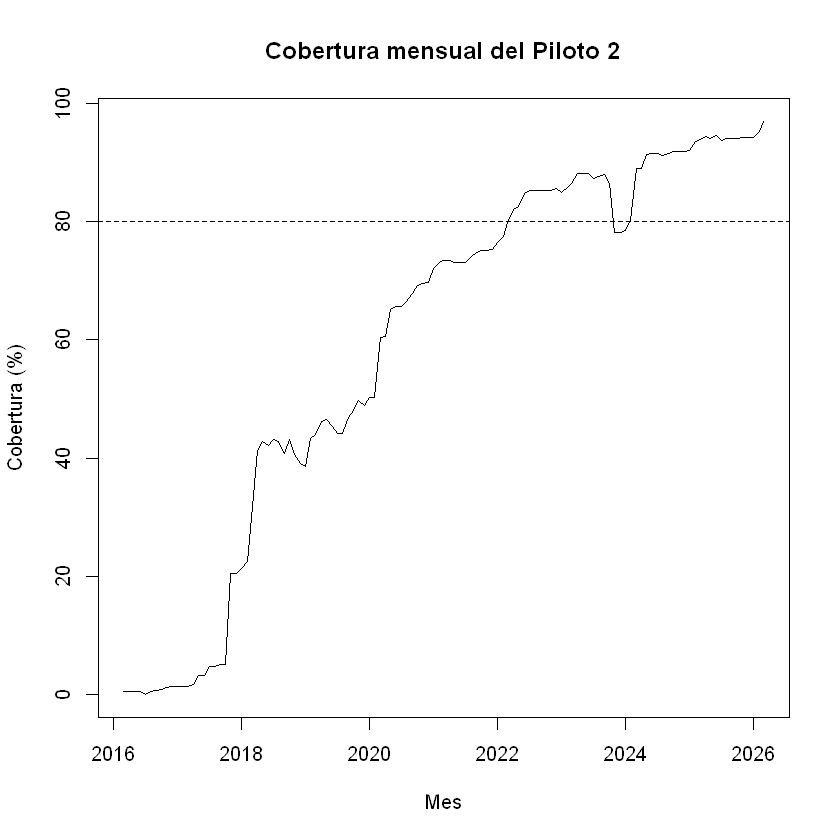

In [58]:
plot(
  monthly_overall_coverage$month,
  monthly_overall_coverage$coverage_pct,
  type = "l",
  xlab = "Mes",
  ylab = "Cobertura (%)",
  main = "Cobertura mensual del Piloto 2"
)

abline(
  h = COVERAGE_THRESHOLD,
  lty = 2
)

In [59]:
# 1. Cobertura máxima y mediana de cada variable Fan Stats
coverage_long <- melt(
  coverage_matrix,
  id.vars = "month",
  variable.name = "variable",
  value.name = "coverage_pct"
)

coverage_long[
  ,
  .(
    primer_mes_con_datos = min(
      month[coverage_pct > 0]
    ),
    cobertura_mediana = median(coverage_pct),
    cobertura_maxima = max(coverage_pct)
  ),
  by = variable
]

variable,primer_mes_con_datos,cobertura_mediana,cobertura_maxima
<fct>,<date>,<dbl>,<dbl>
fan_stats__instagram__followers,2016-03-01,16.666667,21.33333
fan_stats__spotify__followers,2018-03-01,22.333333,24.66667
fan_stats__spotify__listeners,2018-03-01,22.333333,24.66667
fan_stats__tiktok__followers,2020-05-01,5.666667,16.00000
fan_stats__tiktok__likes,2020-05-01,5.666667,16.00000
fan_stats__twitter__followers,2017-11-01,15.333333,20.33333
fan_stats__youtube_artist__monthly_views,2020-03-01,12.666667,13.66667
fan_stats__youtube_channel__subscribers,2017-11-01,15.000000,23.00000
fan_stats__youtube_channel__views,2017-11-01,16.666667,22.66667


In [60]:
# 2. Resumen de la cobertura temporal global
monthly_overall_coverage[
  ,
  .(
    primer_mes = min(month),
    ultimo_mes = max(month),
    cobertura_minima = min(coverage_pct),
    cobertura_mediana = median(coverage_pct),
    cobertura_maxima = max(coverage_pct)
  )
]

primer_mes,ultimo_mes,cobertura_minima,cobertura_mediana,cobertura_maxima
<date>,<date>,<dbl>,<dbl>,<dbl>
2016-03-01,2026-03-01,0,73.15315,96.93694


In [61]:
# 3. Primeros meses que alcanzan 80%
head(
  good_coverage_months,
  12
)

month,series_con_dato,series_esperadas,coverage_pct
<date>,<int>,<int>,<dbl>
2022-04-01,455,555,81.98198
2022-05-01,458,555,82.52252
2022-06-01,470,555,84.68468
2022-07-01,473,555,85.22523
2022-08-01,473,555,85.22523
2022-09-01,473,555,85.22523
2022-10-01,473,555,85.22523
2022-11-01,473,555,85.22523
2022-12-01,475,555,85.58559


In [62]:
# 4. Últimos 24 meses de cobertura temporal
tail(
  monthly_overall_coverage,
  24
)

month,series_con_dato,series_esperadas,coverage_pct
<date>,<int>,<int>,<dbl>
2024-04-01,494,555,89.00901
2024-05-01,507,555,91.35135
2024-06-01,508,555,91.53153
2024-07-01,508,555,91.53153
2024-08-01,506,555,91.17117
2024-09-01,508,555,91.53153
2024-10-01,510,555,91.89189
2024-11-01,510,555,91.89189
2024-12-01,510,555,91.89189


In [63]:
# ============================================================
# DIAGNÓSTICO DE LOS MESES CON MENOR COBERTURA
# desde abril de 2022
# ============================================================

monthly_overall_coverage[
  month >= as.Date("2022-04-01")
][
  order(coverage_pct)
][
  1:15
]

month,series_con_dato,series_esperadas,coverage_pct
<date>,<int>,<int>,<dbl>
2023-11-01,434,555,78.19820
2023-12-01,434,555,78.19820
2024-01-01,436,555,78.55856
2024-02-01,445,555,80.18018
2022-04-01,455,555,81.98198
2022-05-01,458,555,82.52252
2022-06-01,470,555,84.68468
2023-01-01,471,555,84.86486
2022-07-01,473,555,85.22523



## 15. Qué decidir después del Piloto 2

1. desde qué mes existe cobertura cross-artists aceptable;
2. qué variables tienen cobertura suficiente para entrar al clustering;
3. si exigir simultáneamente todas las variables es demasiado restrictivo;
4. cómo tratar `interpolated` y `extrapolated`;
5. profundidad histórica real de Playlist Evolution;
6. tamaño final de la muestra de artistas;
7. estrategia definitiva de almacenamiento antes de escalar a cientos o miles de artistas.



# ATENCION

noviembre 2023–febrero 2024 cae la cobertura global a aproximadamente 81–83% y luego vuelve por encima de 91%. Eso parece más un hueco de datos que una cuestión de adopción de plataformas